# Stock Price Forecasting: ARIMA vs Prophet vs LSTM

Comparative evaluation of three time-series forecasting models on Infosys (INFY) historical stock prices.

## Objective

The objective of this project is to compare three forecasting approaches:

- **ARIMA** — classical statistical time-series model
- **Prophet** — trend and seasonality-based forecasting model
- **LSTM** — deep-learning model for sequential data

All three models are evaluated on the same stock and test period using the same error metrics.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Project Overview

This project follows a chronological train-test evaluation framework.

**Dataset:** Infosys Ltd. (INFY)  
**Data source:** Yahoo Finance  
**Period:** January 2019 – December 2025  
**Target variable:** Daily closing price  
**Train/Test split:** 90% / 10%  
**Evaluation metrics:** RMSE and MAE

The test set is kept completely separate from model training to evaluate performance on unseen observations.

# 1. Data Preparation

## Data Collection

Historical daily closing-price data for Infosys (INFY) is retrieved using Yahoo Finance.

In [ ]:
data = yf.download("INFY.NS", start="2019-01-01", end="2026-01-01")
close = data['Close'].dropna()

/tmp/ipykernel_524/3388239586.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("INFY.NS", start="2019-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


## Train-Test Split

The dataset is divided chronologically into 90% training data and 10% testing data.

No random shuffling is performed because the temporal order of observations must be preserved in time-series forecasting.

In [ ]:
train_size = int(len(close) * 0.9)
train, test = close[:train_size], close[train_size:]

# 2. ARIMA

In [ ]:
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

## 2.1 Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether the stock-price series is stationary.

A p-value greater than 0.05 indicates that we cannot reject the null hypothesis of a unit root.

In [ ]:
result = adfuller(close)
print(f"ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")

ADF Statistic: -1.5932, p-value: 0.4870


/tmp/ipykernel_524/40008621.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(close)


### Result

The ADF test produced a p-value of 0.4870.

Therefore, the original closing-price series is not stationary at the 5% significance level.

## 2.2 Automatic Model Selection

`auto_arima()` is used to automatically search for an appropriate combination of ARIMA parameters `(p, d, q)` using only the training data.

In [ ]:
# Auto-select p, d, q

arima_model = pm.auto_arima(
    np.asarray(train).ravel(),
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=13710.994, Time=1.56 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=13705.833, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=13706.861, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=13706.841, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=13705.050, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=13707.015, Time=0.86 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.020 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1557
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -6851.525
Date:                Thu, 17 Sep 2026   AIC                          13705.050
Time:                        17:21:20   BIC                          13710.400
Sample:                             0   HQIC                         13707.040
    

## 2.3 Forecasting and Evaluation

The trained ARIMA model generates forecasts for the entire test period.

Performance is evaluated using RMSE and MAE.

In [ ]:
# Generate ARIMA forecast

arima_forecast = arima_model.predict(n_periods=len(test))

arima_rmse = np.sqrt(
    mean_squared_error(np.asarray(test).ravel(), np.asarray(arima_forecast).ravel())
)

arima_mae = mean_absolute_error(
    np.asarray(test).ravel(), np.asarray(arima_forecast).ravel()
)

print(f"ARIMA - RMSE: {arima_rmse:.2f}, MAE: {arima_mae:.2f}")

ARIMA - RMSE: 106.37, MAE: 88.35


## 2.4 Forecast Visualization

The following plot compares the actual test-set prices with the ARIMA forecasts.

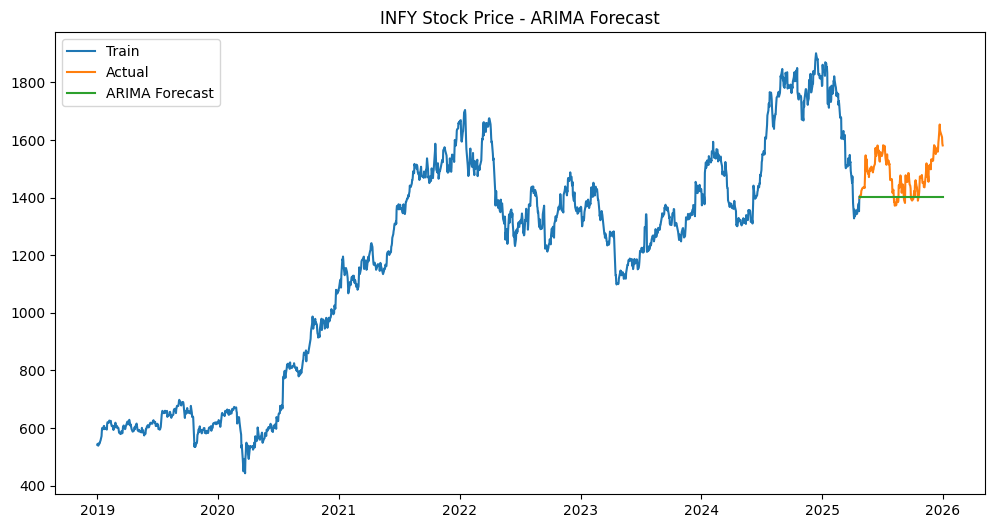

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.title("INFY Stock Price - ARIMA Forecast")
plt.show()

# 3. PROPHET

In [ ]:
from prophet import Prophet

df = pd.DataFrame({'ds': close.index, 'y': close.values.flatten()})
train_p, test_p = df[:train_size], df[train_size:]

## 3.1 Model Configuration

Prophet is configured with weekly and yearly seasonality while daily seasonality is disabled.

In [ ]:
prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(train_p)

## 3.2 Model Training

The model is trained exclusively on the training portion of the dataset.

In [ ]:
future = prophet_model.make_future_dataframe(periods=len(test_p))
forecast = prophet_model.predict(future)
prophet_forecast = forecast.iloc[-len(test_p):]['yhat'].values
actual_p = test_p['y'].values

## 3.3 Forecasting and Evaluation

The trained PROPHET model generates forecasts for the entire test period.

Performance is evaluated using RMSE and MAE.

In [ ]:
prophet_rmse = np.sqrt(mean_squared_error(actual_p, prophet_forecast))
prophet_mae = mean_absolute_error(actual_p, prophet_forecast)
print(f"Prophet - RMSE: {prophet_rmse:.2f}, MAE: {prophet_mae:.2f}")

Prophet - RMSE: 347.09, MAE: 319.95


## 3.4 Forecast Visualization

The following plot compares the actual test-set prices with the Prophet forecasts.

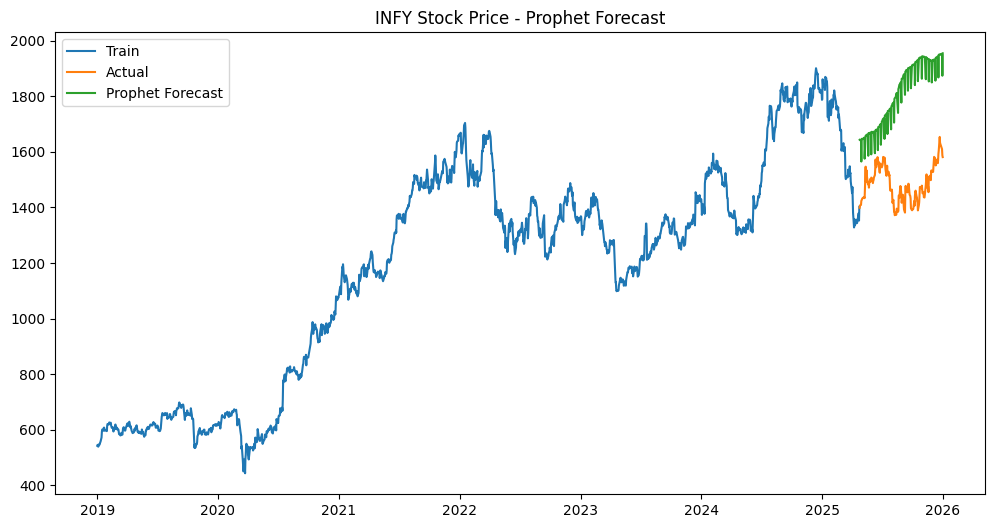

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train_p['ds'], train_p['y'], label="Train")
plt.plot(test_p['ds'], test_p['y'], label="Actual")
plt.plot(test_p['ds'], prophet_forecast, label="Prophet Forecast")
plt.legend()
plt.title("INFY Stock Price - Prophet Forecast")
plt.show()

# 4. LSTM

In [ ]:
import random
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## 4.1 Data Scaling

The closing prices are normalized using MinMaxScaler before being provided to the neural network.

In [ ]:
close_vals = close.values.reshape(-1, 1)
train_data, test_data = close_vals[:train_size], close_vals[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)

window_size = 60

## 4.2 Sequence Generation

A sliding window of 60 trading days is used to construct the input sequences.

Each sequence contains the previous 60 observations and is used to predict the following observation.

In [ ]:
def create_sequences(dataset, window_size):
    X, y = [], []
    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window_size)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

## 4.3 Model Architecture

The LSTM consists of:

- LSTM layer: 50 units
- Dropout: 20%
- LSTM layer: 50 units
- Dropout: 20%
- Dense output layer

In [ ]:
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=1)

Epoch 1/25


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0363
Epoch 2/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0053
Epoch 3/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0048
Epoch 4/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0041
Epoch 5/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0038
Epoch 6/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0035
Epoch 7/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0035
Epoch 8/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0033
Epoch 9/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0032
Epoch 10/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0032
Epoch 11/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0030
Epoch 12/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0030
Epoch 13/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0029
Epoch 14/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0029
Epoch 15/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0030
Epoch 16/25
47

## 4.4 Model Training

The model is trained for 25 epochs with a batch size of 32.

In [ ]:
full_data = np.concatenate([train_data[-window_size:], test_data])
full_scaled = scaler.transform(full_data)
X_test, y_test = create_sequences(full_scaled, window_size)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

predicted_scaled = lstm_model.predict(X_test)
lstm_forecast = scaler.inverse_transform(predicted_scaled)
actual_l = scaler.inverse_transform(y_test.reshape(-1, 1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


## 4.5 Forecasting and Evaluation

The predictions are transformed back to the original price scale and evaluated using RMSE and MAE.

In [ ]:
lstm_rmse = np.sqrt(mean_squared_error(actual_l, lstm_forecast))
lstm_mae = mean_absolute_error(actual_l, lstm_forecast)
print(f"LSTM - RMSE: {lstm_rmse:.2f}, MAE: {lstm_mae:.2f}")

LSTM - RMSE: 37.18, MAE: 30.53


## 4.6 Forecast Visualization

The following plot compares the actual test-set prices with the LSTM forecasts.

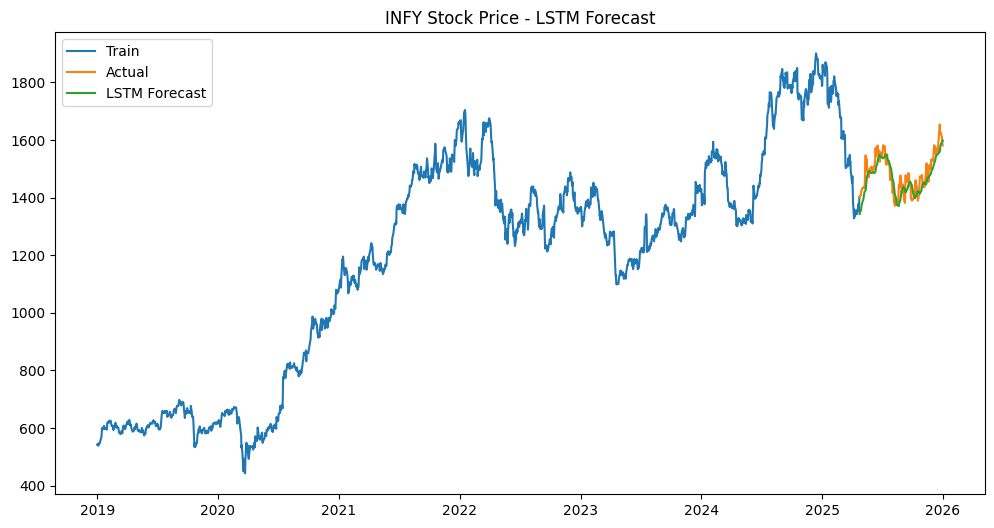

In [ ]:
test_dates = close.index[train_size:]
plt.figure(figsize=(12,6))
plt.plot(close.index[:train_size], train_data, label="Train")
plt.plot(test_dates, test_data, label="Actual")
plt.plot(test_dates, lstm_forecast, label="LSTM Forecast")
plt.legend()
plt.title("INFY Stock Price - LSTM Forecast")
plt.show()

# 5. Naive Baseline

A simple naive forecasting strategy is included as a baseline.

The prediction for each day is the previous day's actual closing price.

This provides a reference point for determining whether the more sophisticated models provide an improvement over a simple persistence-based forecast.

In [ ]:
naive_input = np.concatenate([train_data[-1:], test_data[:-1]])
naive_rmse = np.sqrt(mean_squared_error(test_data, naive_input))
naive_mae = mean_absolute_error(test_data, naive_input)
print(f"Naive Baseline - RMSE: {naive_rmse:.2f}, MAE: {naive_mae:.2f}")

Naive Baseline - RMSE: 20.87, MAE: 14.76


# 6. Model Comparison

The three forecasting models are now evaluated against the naive baseline using the same test dataset.

## Performance Metrics

| Model | RMSE | MAE |
|---|---:|---:|
| Naive Baseline | 20.87 | 14.76 |
| ARIMA | 106.37 | 88.35 |
| Prophet | 346.58 | 319.46 |
| LSTM | 37.18 | 30.53 |

Lower RMSE and MAE indicate smaller prediction errors.

## Forecast Comparison

The following visualization compares the predictions of all models against the actual stock prices during the test period.

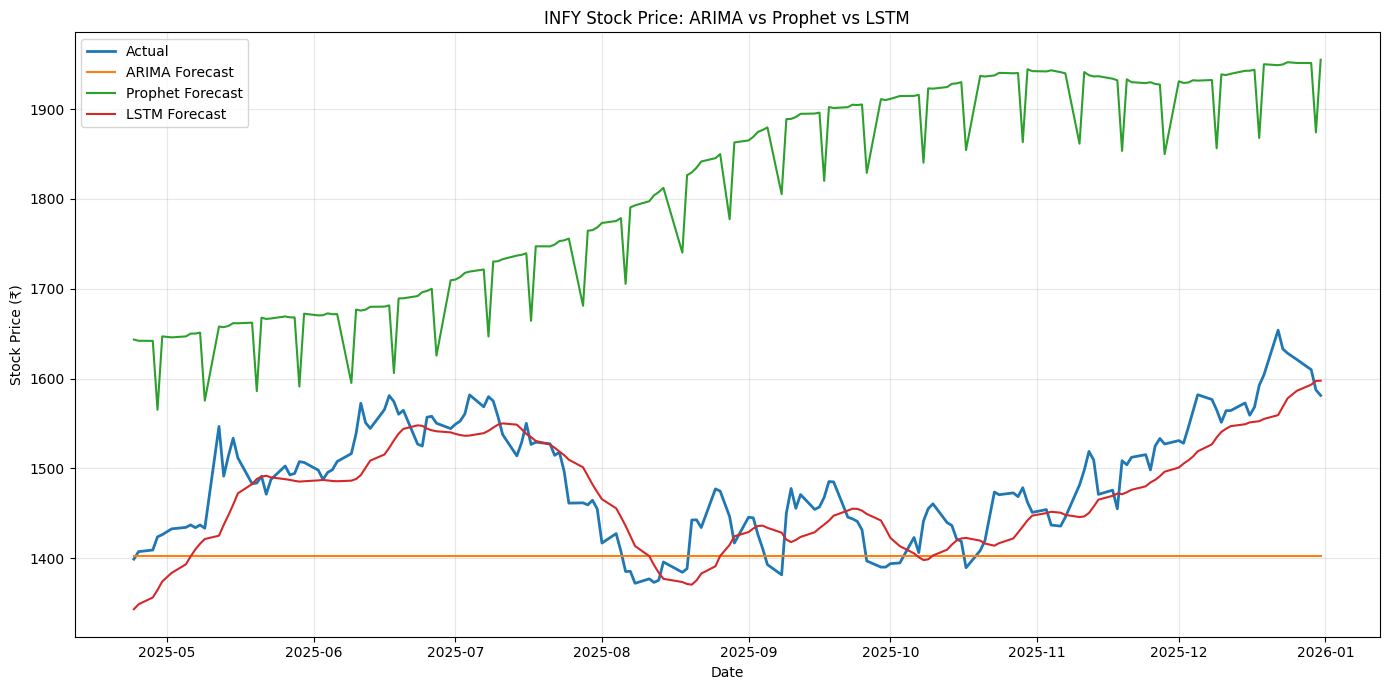

In [ ]:
# Compare ARIMA, Prophet, and LSTM forecasts

plt.figure(figsize=(14, 7))

# Actual prices
plt.plot(test.index, test.values.flatten(), label="Actual", linewidth=2)

# ARIMA
plt.plot(test.index, np.array(arima_forecast).flatten(),
         label="ARIMA Forecast")

# Prophet
plt.plot(test.index, np.array(prophet_forecast).flatten(),
         label="Prophet Forecast")

# LSTM
plt.plot(test.index, np.array(lstm_forecast).flatten(),
         label="LSTM Forecast")

plt.title("INFY Stock Price: ARIMA vs Prophet vs LSTM")
plt.xlabel("Date")
plt.ylabel("Stock Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Conclusion

This project compared ARIMA, Prophet, LSTM, and a naive baseline for forecasting Infosys closing prices.

The comparison demonstrates how different modelling approaches perform when evaluated on the same historical data and unseen test period.

The results should be interpreted specifically as **forecasting performance**, rather than as evidence that a model can reliably generate investment returns.

### Key Takeaways

- Historical stock prices contain substantial variability that makes accurate forecasting difficult.
- Model complexity does not necessarily translate into lower forecasting error.
- A naive baseline provides an important reference for evaluating whether sophisticated models add predictive value.
- RMSE and MAE measure forecast accuracy but do not directly measure investment profitability.